In [47]:
import scanpy as sc
import muon as mu
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", message=".*was not registered in the param store.*")
warnings.filterwarnings("ignore", message=".*Found plate statements in guide but not model.*")

In [48]:
# ATAC lymphoma dataset

mdata = mu.read_h5mu("/data/nelkazwi/share-topic/lymphoma_data/mdata_lymphoma.h5mu")

/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [49]:
# binarize the ATAC data
mdata.mod["atac"].X.data = (mdata.mod["atac"].X.data > 0).astype(int)

In [50]:
# Create a copy first
mdata_filtered = mdata.copy()

# For RNA: remove genes with zero total counts
rna_total_counts = np.array(mdata_filtered.mod["rna"].X.sum(axis=0)).flatten()
rna_nonzero_genes = rna_total_counts > 0
print(f"RNA: Keeping {rna_nonzero_genes.sum()}/{len(rna_nonzero_genes)} genes with non-zero counts")
mdata_filtered.mod["rna"] = mdata_filtered.mod["rna"][:, rna_nonzero_genes]

# For ATAC: remove regions with zero total counts
atac_total_counts = np.array(mdata_filtered.mod["atac"].X.sum(axis=0)).flatten()
atac_nonzero_regions = atac_total_counts > 0
print(f"ATAC: Keeping {atac_nonzero_regions.sum()}/{len(atac_nonzero_regions)} regions with non-zero counts")
mdata_filtered.mod["atac"] = mdata_filtered.mod["atac"][:, atac_nonzero_regions]

# Now compute highly variable features
n_rna = min(2000, mdata_filtered.mod["rna"].n_vars)
n_atac = min(10000, mdata_filtered.mod["atac"].n_vars)

print(f"\nComputing {n_rna} HVGs for RNA...")
sc.pp.highly_variable_genes(mdata_filtered.mod["rna"], n_top_genes=n_rna, flavor="seurat_v3", subset=True)

print(f"Computing {n_atac} HVGs for ATAC...")
sc.pp.highly_variable_genes(mdata_filtered.mod["atac"], n_top_genes=n_atac, flavor="seurat_v3", subset=True)

print("\nFinal dimensions:")
print(f"  RNA: {mdata_filtered.mod['rna'].shape}")
print(f"  ATAC: {mdata_filtered.mod['atac'].shape}")
print(f"  Total: {mdata_filtered.mod['rna'].n_vars + mdata_filtered.mod['atac'].n_vars} features")

/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


RNA: Keeping 8095/8095 genes with non-zero counts
ATAC: Keeping 25812/25812 regions with non-zero counts

Computing 2000 HVGs for RNA...


/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:174: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


Computing 10000 HVGs for ATAC...


/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:174: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}



Final dimensions:
  RNA: (14566, 2000)
  ATAC: (14566, 10000)
  Total: 12000 features


In [51]:
from topomics.models import MultimodalAmortizedLDA

# Create model directly from MuData with automatic extraction
model = MultimodalAmortizedLDA.from_data(
    mdata,
    modalities=["rna", "atac"],  # specify which modalities to use
    n_topics=10,
    likelihoods=["gamma_poisson", "bernoulli"],  # one per modality
    n_hidden=64,
    cell_topic_prior=1 / 10,
    weight_mode="cell",
)

In [52]:
# There is no spatial information in this dataset
print("spatial flag:", model.spatial)
print("use_gcn:", model.module.guide.use_gcn)
print("gcn encoders:", model.module.guide.gcn_encoders is not None)

spatial flag: False
use_gcn: False
gcn encoders: False


In [53]:
# It takes quite a bit to train the model, but 400 epochs should be enough
# to reach a plateau

model.train(
    max_epochs=500,
    batch_size=128,
    train_size=0.8,
    validation_size=0.2,
    log_every_n_steps=1,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.
/scratch/fcaretti/topomics_uv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=111` in the `DataLoader` to improve performance.


Epoch 335/500:  67%|██████▋   | 334/500 [33:46<19:44,  7.13s/it, v_num=1, elbo_val=9.66e+7, elbo_train=3.86e+8]


Detected KeyboardInterrupt, attempting graceful shutdown ...


Text(0, 0.5, 'ELBO')

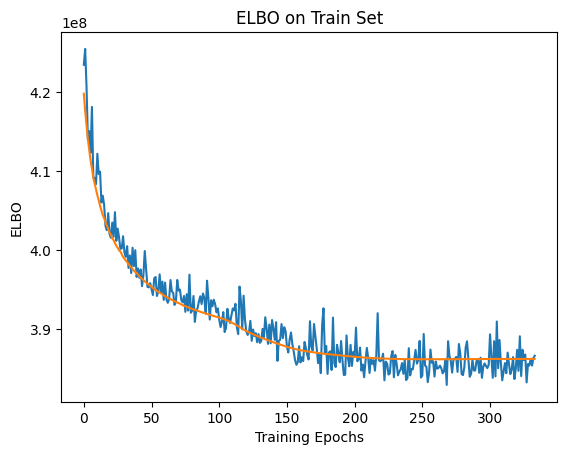

In [54]:
plt.plot(model.history["elbo_train"])
plt.plot(model.history["elbo_val"] * 4)  # rescale to compare train/test differences
plt.title("ELBO on Train Set")
plt.xlabel("Training Epochs")
plt.ylabel("ELBO")

In [55]:
# This API is terrible, I really need to change it

adata_concat = mdata.uns["_flattened_ann_data"]

# Get latent representation
theta = model.get_latent_representation(adata_concat, batch_size=mdata.n_obs)

In [56]:
mdata.obsm["X_topic"] = theta.values - 1 / theta.values.shape[1]

sc.pp.neighbors(mdata, use_rep="X_topic", n_neighbors=15, metric="cosine")
sc.tl.umap(mdata, min_dist=0.3)

# 3) Get dominant topic per cell
mdata.obs["dominant_topic"] = theta.idxmax(axis=1).values

# 4) IMPORTANT: Clean up any old color information to avoid conflicts
if "dominant_topic_colors" in mdata.uns:
    del mdata.uns["dominant_topic_colors"]

# 5) Convert to categorical for better plotting
mdata.obs["dominant_topic"] = pd.Categorical(mdata.obs["dominant_topic"])

In [57]:
mdata

MuData object with n_obs × n_vars = 14566 × 33907
  obs:	'dominant_topic'
  var:	'n_cells'
  uns:	'mofa', 'neighbors', 'umap', '_multimodal_setup', '_flattened_ann_data'
  obsm:	'X_mofa', 'X_umap', 'X_topic'
  varm:	'LFs'
  obsp:	'connectivities', 'distances'
  2 modalities
    atac:	14566 x 25812
      obs:	'cell_types'
      var:	'n_cells'
    rna:	14566 x 8095
      obs:	'cell_types'
      var:	'gene_ids', 'feature_types', 'n_cells'

In [58]:
mdata.obs["cell_type"] = mdata["rna"].obs["cell_types"]

<Axes: title={'center': 'UMAP colored by Cell Type'}, xlabel='X_umap1', ylabel='X_umap2'>

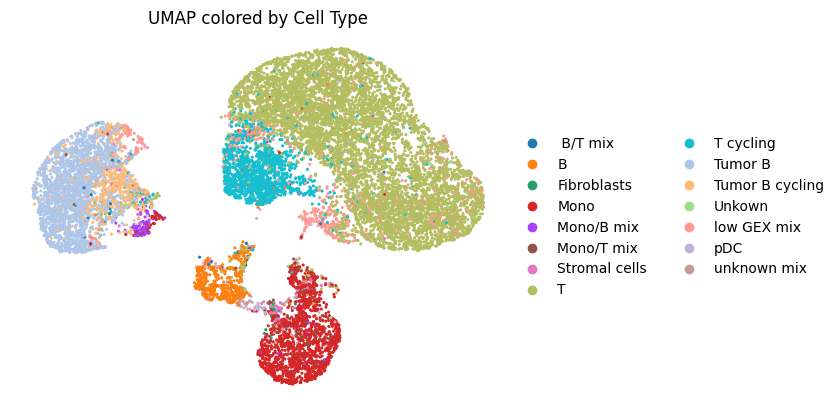

In [59]:
mu.pl.embedding(
    mdata,
    basis="X_umap",
    color="cell_type",
    frameon=False,
    s=20,
    title="UMAP colored by Cell Type",
    show=False,
    legend_loc="right margin",
)

In [60]:
print("\n" + "=" * 70)
print("TOPIC ABUNDANCE SUMMARY")
print("=" * 70)

summary_df = pd.DataFrame(
    {
        "Mean": theta.mean(),
        "Std": theta.std(),
        "Min": theta.min(),
        "Max": theta.max(),
        "# Dominant Spots": [(theta.idxmax(axis=1) == topic).sum() for topic in theta.columns],
    }
)

print(summary_df.round(3).to_string())


TOPIC ABUNDANCE SUMMARY
          Mean    Std  Min    Max  # Dominant Spots
topic_0  0.042  0.075  0.0  0.468                93
topic_1  0.067  0.166  0.0  0.760              1548
topic_2  0.215  0.207  0.0  0.781              5481
topic_3  0.058  0.085  0.0  0.943               332
topic_4  0.132  0.157  0.0  0.680              2584
topic_5  0.082  0.082  0.0  0.537               264
topic_6  0.190  0.107  0.0  0.731               707
topic_7  0.036  0.075  0.0  0.571               368
topic_8  0.115  0.210  0.0  0.749              3092
topic_9  0.064  0.070  0.0  0.584                97


In [61]:
print("=" * 80)
print("TESTING ALL NEW METRICS")
print("=" * 80)

# ============================================================================
# 1. Overall Perplexity
# ============================================================================
print("\n1. OVERALL PERPLEXITY (lower is better)")
print("-" * 80)
perplexity = model.get_perplexity()
print(f"Perplexity: {perplexity:.4f}")

TESTING ALL NEW METRICS

1. OVERALL PERPLEXITY (lower is better)
--------------------------------------------------------------------------------
Perplexity: 0.0031


In [62]:
# ============================================================================
# 2. Per-Modality Perplexity
# ============================================================================
print("\n2. PER-MODALITY PERPLEXITY (lower is better)")
print("-" * 80)
perplexity_per_mod = model.get_perplexity_per_modality()
for mod_name, ppl in perplexity_per_mod.items():
    print(f"  {mod_name}: {ppl:.4f}")


2. PER-MODALITY PERPLEXITY (lower is better)
--------------------------------------------------------------------------------
  rna: 925607035172450963852428902838442887743263627501899015222790877604162306048.0000
  atac: inf


/u/f/fcaretti/topomics/src/topomics/models/amortizedLDA.py:1362: RuntimeWarning: overflow encountered in exp
  mod_name: float(np.exp(-log_lik / per_mod_counts[m]))


In [63]:
# ============================================================================
# 3. Per-Modality Log-Likelihood
# ============================================================================
print("\n3. PER-MODALITY LOG-LIKELIHOOD (higher is better)")
print("-" * 80)
likelihood_per_mod = model.get_likelihood_per_modality()
for mod_name, ll in likelihood_per_mod.items():
    print(f"  {mod_name}: {ll:.2f}")


3. PER-MODALITY LOG-LIKELIHOOD (higher is better)
--------------------------------------------------------------------------------
  rna: -6761955584.00
  atac: -48023856480.00


In [64]:
# ============================================================================
# 4. Entropy
# ============================================================================
print("\n4. ENTROPY (higher = more evenly distributed topics)")
print("-" * 80)
entropy = model.get_entropy(normalised=True)
print(f"Mean cell-topic entropy: {entropy:.4f}")
print(f"Max possible entropy (uniform): {np.log(model.n_topics):.4f}")
print(f"Normalized entropy: {entropy / np.log(model.n_topics):.2%}")


4. ENTROPY (higher = more evenly distributed topics)
--------------------------------------------------------------------------------
Mean cell-topic entropy: 1.4240
Max possible entropy (uniform): 2.3026
Normalized entropy: 61.85%


In [65]:
# ============================================================================
# 5. Topic Diversity
# ============================================================================
print("\n5. TOPIC DIVERSITY (higher = more distinct topics)")
print("-" * 80)

# Overall diversity
diversity_all = model.get_topic_diversity()
print(f"Overall diversity (avg across modalities): {diversity_all:.4f}")

# Per-modality diversity
print("\nPer-modality diversity:")
diversity_rna = model.get_topic_diversity(modality="rna")
diversity_atac = model.get_topic_diversity(modality="atac")
print(f"  RNA: {diversity_rna:.4f}")
print(f"  ATAC: {diversity_atac:.4f}")


5. TOPIC DIVERSITY (higher = more distinct topics)
--------------------------------------------------------------------------------
Overall diversity (avg across modalities): 0.4540

Per-modality diversity:
  RNA: 0.6555
  ATAC: 0.2525


In [66]:
# ============================================================================
# 6. Top Features Per Topic
# ============================================================================
print("\n6. TOP FEATURES PER TOPIC")
print("-" * 80)

# Get top 10 genes per topic for RNA
top_genes = model.get_top_features_per_topic(modality="rna", n_features=10, return_scores=False)
print("\nTop 10 genes for first 3 topics (RNA):")
for topic_id in list(top_genes.keys())[:3]:
    print(f"\n  {topic_id}:")
    for gene in top_genes[topic_id]:
        print(f"    - {gene}")

# Get top regions with scores for ATAC
top_regions_with_scores = model.get_top_features_per_topic(modality="atac", n_features=5, return_scores=True)
print("\nTop 5 ATAC regions for topic_0 (with scores):")
for region, score in top_regions_with_scores["topic_0"]:
    print(f"  {region}: {score:.4f}")


6. TOP FEATURES PER TOPIC
--------------------------------------------------------------------------------

Top 10 genes for first 3 topics (RNA):

  topic_0:
    - ASPM
    - RRM2
    - POLQ
    - DTL
    - DIAPH3
    - TOP2A
    - MELK
    - BRIP1
    - FANCI
    - CENPP

  topic_1:
    - SLC8A1
    - LRMDA
    - KCNMA1
    - AL162414.1
    - DOCK4
    - PLXDC2
    - FMNL2
    - TNFAIP2
    - DAPK1
    - RBM47

  topic_2:
    - LINC01934
    - THEMIS
    - AGAP1
    - CADM1
    - INPP4B
    - AL133405.2
    - GNLY
    - PRKCH
    - LAG3
    - BCL11B

Top 5 ATAC regions for topic_0 (with scores):
  chr13:113584313-113585103: 0.0002
  chr2:10122156-10123078: 0.0002
  chr5:177311796-177312709: 0.0002
  chr11:19240658-19241537: 0.0002
  chr1:226308762-226309651: 0.0002


In [67]:
# ============================================================================
# 7. Modality Weights (NEW!)
# ============================================================================
print("\n7. MODALITY WEIGHTS (shows which modality model relies on more)")
print("-" * 80)
weights = model.get_modality_weights()
print(f"\nWeights shape: {weights.shape}")
print(f"Weight mode: {model.weight_mode}")

# Summary statistics
print("\nAverage weight per modality:")
for mod_name in weights.columns:
    mean_weight = weights[mod_name].mean()
    std_weight = weights[mod_name].std()
    print(f"  {mod_name}: {mean_weight:.4f} ± {std_weight:.4f}")

# Cells where RNA dominates
rna_dominant = (weights["rna"] > 0.6).sum()
atac_dominant = (weights["atac"] > 0.6).sum()
balanced = ((weights["rna"] > 0.4) & (weights["rna"] < 0.6)).sum()
print("\nCell distribution:")
print(f"  RNA-dominant (>0.6): {rna_dominant} cells ({rna_dominant / len(weights) * 100:.1f}%)")
print(f"  ATAC-dominant (>0.6): {atac_dominant} cells ({atac_dominant / len(weights) * 100:.1f}%)")
print(f"  Balanced (0.4-0.6): {balanced} cells ({balanced / len(weights) * 100:.1f}%)")


7. MODALITY WEIGHTS (shows which modality model relies on more)
--------------------------------------------------------------------------------

Weights shape: (14566, 2)
Weight mode: cell

Average weight per modality:
  rna: 0.5003 ± 0.0032
  atac: 0.4997 ± 0.0032

Cell distribution:
  RNA-dominant (>0.6): 0 cells (0.0%)
  ATAC-dominant (>0.6): 0 cells (0.0%)
  Balanced (0.4-0.6): 14566 cells (100.0%)



8. CROSS-MODALITY INTERACTION SCORE
--------------------------------------------------------------------------------
Cross-modality score matrix shape: (8095, 25812)
Mean interaction score: 0.0543
Max interaction score: 1.0000

GENERATING VISUALIZATIONS

Saved visualization to: topic_model_metrics.png


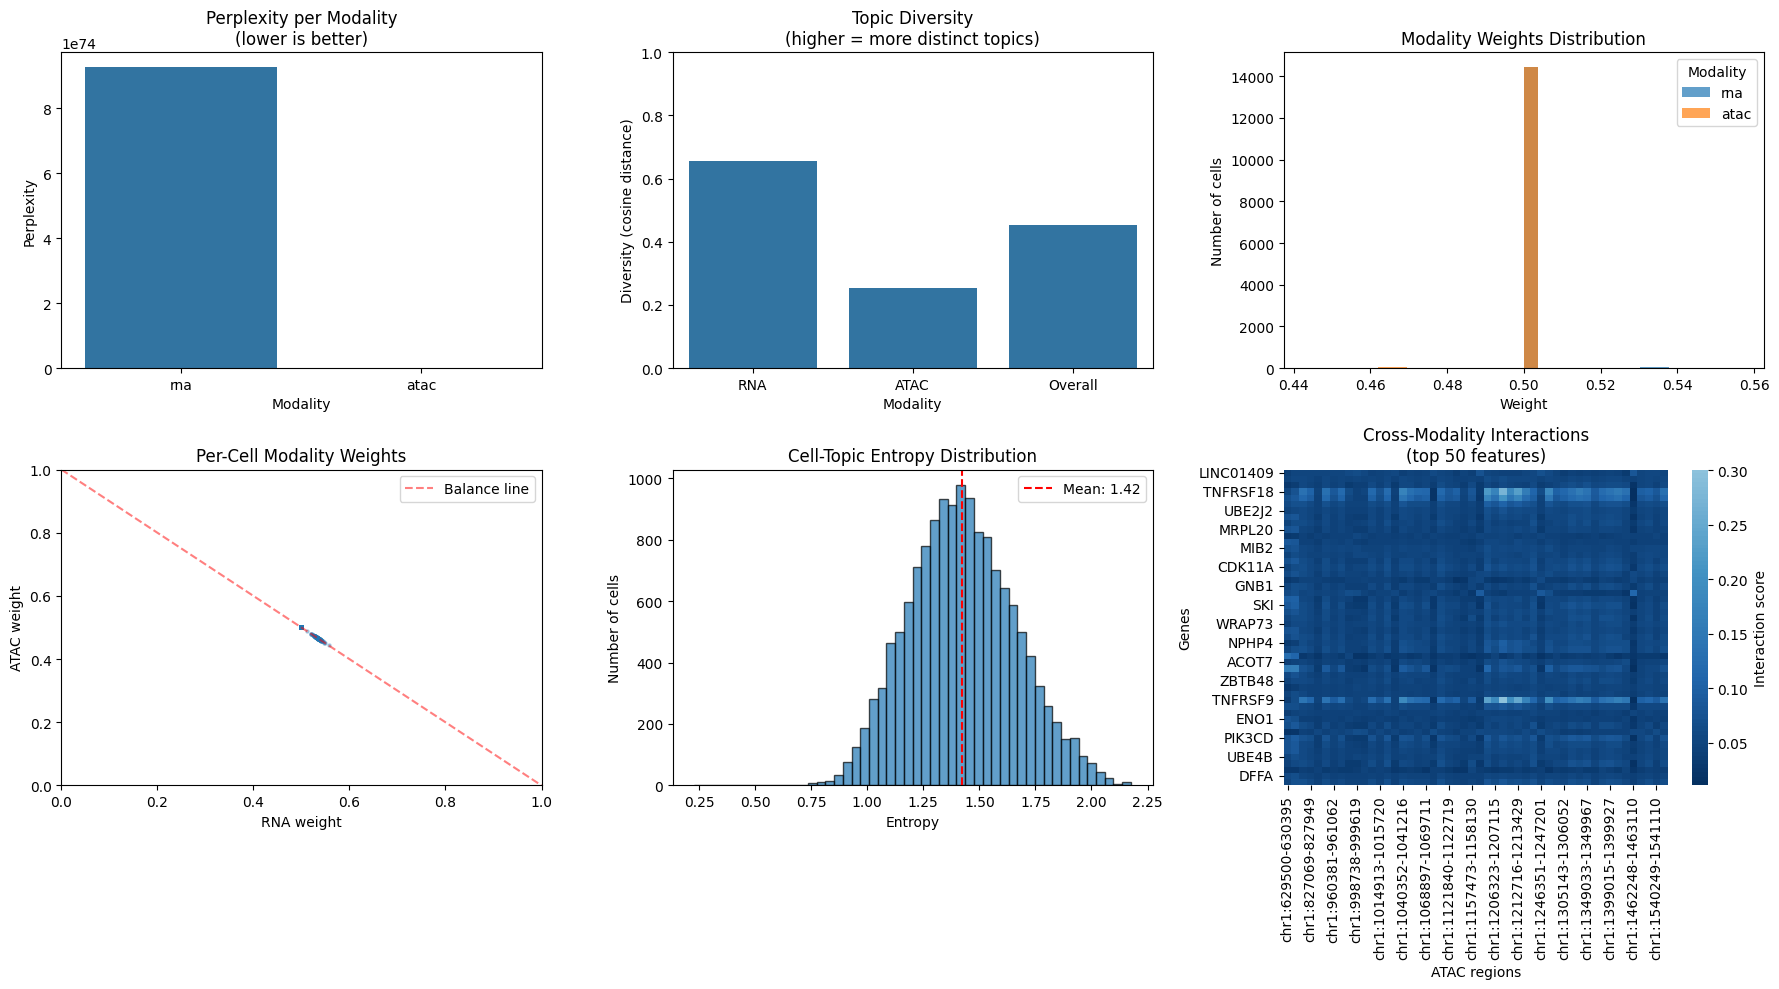


BONUS: TOPIC-SPECIFIC ANALYSIS

Topic assignments (most probable topic per cell):
  Topic 0: 105 cells (0.7%)
  Topic 1: 1560 cells (10.7%)
  Topic 2: 5486 cells (37.7%)
  Topic 3: 370 cells (2.5%)
  Topic 4: 2646 cells (18.2%)
  Topic 5: 237 cells (1.6%)
  Topic 6: 599 cells (4.1%)
  Topic 7: 376 cells (2.6%)
  Topic 8: 3095 cells (21.2%)
  Topic 9: 92 cells (0.6%)

SUMMARY TABLE
            Metric                                                                            Value                        Interpretation
Overall Perplexity                                                                           0.0031         Lower = better reconstruction
    RNA Perplexity 925607035172450963852428902838442887743263627501899015222790877604162306048.0000     Lower = better RNA reconstruction
   ATAC Perplexity                                                                              inf    Lower = better ATAC reconstruction
      Mean Entropy                                             

In [68]:
# ============================================================================
# 8. Cross-Modality Score (already existed, but included for completeness)
# ============================================================================
print("\n8. CROSS-MODALITY INTERACTION SCORE")
print("-" * 80)
cross_mod_score = model.cross_modality_score(mod_a="rna", mod_b="atac", normalise=True, return_df=True)
print(f"Cross-modality score matrix shape: {cross_mod_score.shape}")
print(f"Mean interaction score: {cross_mod_score.values.mean():.4f}")
print(f"Max interaction score: {cross_mod_score.values.max():.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Perplexity comparison
ax = axes[0, 0]
perp_data = pd.DataFrame({"Modality": list(perplexity_per_mod.keys()), "Perplexity": list(perplexity_per_mod.values())})
sns.barplot(data=perp_data, x="Modality", y="Perplexity", ax=ax)
ax.set_title("Perplexity per Modality\n(lower is better)")
ax.set_ylabel("Perplexity")

# 2. Topic diversity comparison
ax = axes[0, 1]
div_data = pd.DataFrame(
    {"Modality": ["RNA", "ATAC", "Overall"], "Diversity": [diversity_rna, diversity_atac, diversity_all]}
)
sns.barplot(data=div_data, x="Modality", y="Diversity", ax=ax)
ax.set_title("Topic Diversity\n(higher = more distinct topics)")
ax.set_ylabel("Diversity (cosine distance)")
ax.set_ylim(0, 1)

# 3. Modality weights distribution
ax = axes[0, 2]
weights.plot.hist(bins=30, alpha=0.7, ax=ax)
ax.set_title("Modality Weights Distribution")
ax.set_xlabel("Weight")
ax.set_ylabel("Number of cells")
ax.legend(title="Modality")

# 4. Modality weights scatter
ax = axes[1, 0]
ax.scatter(weights["rna"], weights["atac"], alpha=0.3, s=5)
ax.plot([0, 1], [1, 0], "r--", alpha=0.5, label="Balance line")
ax.set_xlabel("RNA weight")
ax.set_ylabel("ATAC weight")
ax.set_title("Per-Cell Modality Weights")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# 5. Cell-topic entropy distribution
ax = axes[1, 1]
theta = model.get_cell_topic_dist()
theta_norm = theta / (theta.sum(axis=1, keepdims=True) + 1e-12)
cell_entropies = -(theta_norm * np.log(np.clip(theta_norm, 1e-8, None))).sum(axis=1)
ax.hist(cell_entropies, bins=50, alpha=0.7, edgecolor="black")
ax.axvline(entropy, color="red", linestyle="--", label=f"Mean: {entropy:.2f}")
ax.set_xlabel("Entropy")
ax.set_ylabel("Number of cells")
ax.set_title("Cell-Topic Entropy Distribution")
ax.legend()

# 6. Cross-modality heatmap (top 50x50 subset for visibility)
ax = axes[1, 2]
subset = cross_mod_score.iloc[:50, :50]
sns.heatmap(subset, cmap="RdBu_r", center=0.5, ax=ax, cbar_kws={"label": "Interaction score"})
ax.set_title("Cross-Modality Interactions\n(top 50 features)")
ax.set_xlabel("ATAC regions")
ax.set_ylabel("Genes")

plt.tight_layout()
plt.savefig("topic_model_metrics.png", dpi=150, bbox_inches="tight")
print("\nSaved visualization to: topic_model_metrics.png")
plt.show()

# ============================================================================
# BONUS: Topic-specific analysis
# ============================================================================
print("\n" + "=" * 80)
print("BONUS: TOPIC-SPECIFIC ANALYSIS")
print("=" * 80)

# Get cell-topic distributions
theta = model.get_cell_topic_dist()

# Find dominant topic per cell
dominant_topics = theta.argmax(axis=1)
print("\nTopic assignments (most probable topic per cell):")
topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
for topic_id, count in topic_counts.items():
    print(f"  Topic {topic_id}: {count} cells ({count / len(theta) * 100:.1f}%)")

# ============================================================================
# Summary table
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)

summary = pd.DataFrame(
    {
        "Metric": [
            "Overall Perplexity",
            "RNA Perplexity",
            "ATAC Perplexity",
            "Mean Entropy",
            "RNA Diversity",
            "ATAC Diversity",
            "Overall Diversity",
            "Mean RNA Weight",
            "Mean ATAC Weight",
        ],
        "Value": [
            f"{perplexity:.4f}",
            f"{perplexity_per_mod['rna']:.4f}",
            f"{perplexity_per_mod['atac']:.4f}",
            f"{entropy:.4f}",
            f"{diversity_rna:.4f}",
            f"{diversity_atac:.4f}",
            f"{diversity_all:.4f}",
            f"{weights['rna'].mean():.4f}",
            f"{weights['atac'].mean():.4f}",
        ],
        "Interpretation": [
            "Lower = better reconstruction",
            "Lower = better RNA reconstruction",
            "Lower = better ATAC reconstruction",
            "Higher = more spread topics",
            "Higher = more distinct RNA topics",
            "Higher = more distinct ATAC topics",
            "Higher = more distinct topics overall",
            "Higher = model trusts RNA more",
            "Higher = model trusts ATAC more",
        ],
    }
)

print(summary.to_string(index=False))

print("\n" + "=" * 80)
print("CACHING STATUS")
print("=" * 80)
print(f"Number of cached metrics: {len(model._cached_metrics)}")
print("Cached metric keys:")
for key in model._cached_metrics.keys():
    print(f"  - {key}")
print("\nNote: Subsequent calls to these metrics will use cached values (instant!)")

In [ ]:
model.save("/data/atac_rna_bernoulli_cell_normalized")